In [1]:

import re
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, Lambda
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import skipgrams
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt


In [2]:

# Enhanced but still safe parameters
EMBEDDING_DIM = 40
WINDOW_SIZE = 2
EPOCHS = 10
MAX_TOKENS = 8000
VOCAB_LIMIT = 2500


In [3]:

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text



## 1️⃣ Load and preprocess AG News dataset (Real-world)

We use the **AG News dataset**, which contains real-world news articles.
The *Title* and *Description* fields are combined to form the text corpus.


In [4]:

import pandas as pd

# Load AG News dataset (upload test.csv to Colab)
df = pd.read_csv("/content/test.csv")

# Combine title and description
text = " ".join(df["Title"] + " " + df["Description"])

# Preprocess
text = preprocess_text(text)

# Limit tokens for faster training
text = " ".join(text.split()[:MAX_TOKENS])

print("Total tokens used:", len(text.split()))


Total tokens used: 8000


## 2️⃣ Tokenization

In [5]:

tokenizer = Tokenizer(num_words=VOCAB_LIMIT)
tokenizer.fit_on_texts([text])
sequence = tokenizer.texts_to_sequences([text])[0]

print("Vocabulary size:", len(tokenizer.word_index))
print("First 15 tokens:", sequence[:15])


Vocabulary size: 2750
First 15 tokens: [1123, 8, 54, 251, 1124, 32, 128, 1125, 1126, 588, 15, 1127, 1128, 589, 55]


## 3️⃣ CBOW Model

In [6]:

def train_cbow(sequence, vocab_size):
    X, y = [], []
    for i in range(WINDOW_SIZE, len(sequence) - WINDOW_SIZE):
        context = sequence[i-WINDOW_SIZE:i] + sequence[i+1:i+WINDOW_SIZE+1]
        X.append(context)
        y.append(sequence[i])

    X = np.array(X)
    y = tf.keras.utils.to_categorical(y, vocab_size)

    input_layer = Input(shape=(2*WINDOW_SIZE,))
    embed = Embedding(vocab_size, EMBEDDING_DIM, input_length=2*WINDOW_SIZE)(input_layer)
    avg = Lambda(lambda x: tf.reduce_mean(x, axis=1))(embed)
    output = Dense(vocab_size, activation='softmax')(avg)

    model = Model(input_layer, output)
    model.compile(loss='categorical_crossentropy', optimizer='adam')
    model.fit(X, y, epochs=EPOCHS, verbose=1)

    return model.layers[1]


In [7]:

train_cbow(sequence, VOCAB_LIMIT)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.7932
Epoch 2/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.3798
Epoch 3/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9332
Epoch 4/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7789
Epoch 5/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6877
Epoch 6/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5912
Epoch 7/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4968
Epoch 8/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3837
Epoch 9/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 6.2944
Epoch 10/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.1457


<Embedding name=embedding, built=True>

## 4️⃣ Skip-gram Model

In [8]:
def train_skipgram(sequence, vocab_size):
    pairs, labels = skipgrams(
        sequence,
        vocab_size,
        window_size=WINDOW_SIZE,
        negative_samples=2,
        seed=42
    )

    target = np.array([p[0] for p in pairs]).reshape(-1, 1)
    context = np.array([p[1] for p in pairs]).reshape(-1, 1)
    labels = np.array(labels)

    inp_t = Input(shape=(1,))
    inp_c = Input(shape=(1,))

    embedding = Embedding(vocab_size, EMBEDDING_DIM)

    emb_t = embedding(inp_t)
    emb_c = embedding(inp_c)

    dot = Lambda(lambda x: tf.reduce_sum(x[0] * x[1], axis=-1))([emb_t, emb_c])
    out = Dense(1, activation='sigmoid')(dot)

    model = Model(inputs=[inp_t, inp_c], outputs=out)
    model.compile(loss='binary_crossentropy', optimizer='adam')

    model.fit(
        x=(target, context),
        y=labels,
        epochs=EPOCHS,
        verbose=0
    )

    print("Skip-gram training complete")
    return embedding

In [9]:

embedding_layer = train_skipgram(sequence, VOCAB_LIMIT)
embeddings = embedding_layer.get_weights()[0]

print("Embedding matrix shape:", embeddings.shape)


Skip-gram training complete
Embedding matrix shape: (2500, 40)


## 5️⃣ Word → Vector Examples (Console Output)

In [10]:

words = list(tokenizer.word_index.keys())[:5]

print("Sample word embeddings (first 8 dimensions):\n")
for w in words:
    idx = tokenizer.word_index[w]
    print(f"{w:>8} → {embeddings[idx][:8]}")


Sample word embeddings (first 8 dimensions):

     the → [-0.20782581  0.00822946 -0.00789413  0.43586788 -0.20323794 -0.52903455
 -0.0549949  -0.01522224]
      to → [ 0.05973535 -0.22056065  0.2630771   0.22028121  0.27678588 -0.32600996
  0.01398292  0.124136  ]
       a → [ 0.25750965 -0.09452262  0.00968734  0.11822381  0.366463   -0.4639132
  0.15111656  0.19319102]
      in → [-0.542729   -0.09562591  0.13767402  0.00177392 -0.01094416 -0.59095305
  0.00289851  0.08191596]
      of → [-0.006071   -0.11404052  0.03026629  0.05254734  0.21818511 -0.29753286
  0.3237399  -0.27655432]


## 6️⃣ Cosine Similarity Examples

In [11]:
def similarity(w1, w2, embedding_matrix):
    if w1 not in tokenizer.word_index or w2 not in tokenizer.word_index:
        return None

    i1 = tokenizer.word_index[w1]
    i2 = tokenizer.word_index[w2]

    return cosine_similarity(
        embedding_matrix[i1].reshape(1, -1),w
        embedding_matrix[i2].reshape(1, -1)
    )[0][0]


print("Cosine similarity examples (AG News dataset):\n")

# Use Skip-gram embeddings (recommended)
print("war vs conflict :", similarity("war", "conflict", embeddings))
print("market vs economy :", similarity("market", "economy", embeddings))
print("technology vs science :", similarity("technology", "science", embeddings))
print("sports vs game :", similarity("sports", "game", embeddings))
print("war vs market :", similarity("war", "market", embeddings))

Cosine similarity examples (AG News dataset):

war vs conflict : 0.2387339
market vs economy : 0.048897546
technology vs science : None
sports vs game : -0.18412638
war vs market : 0.011960803


## 7️⃣ Visualization (PCA Projection)

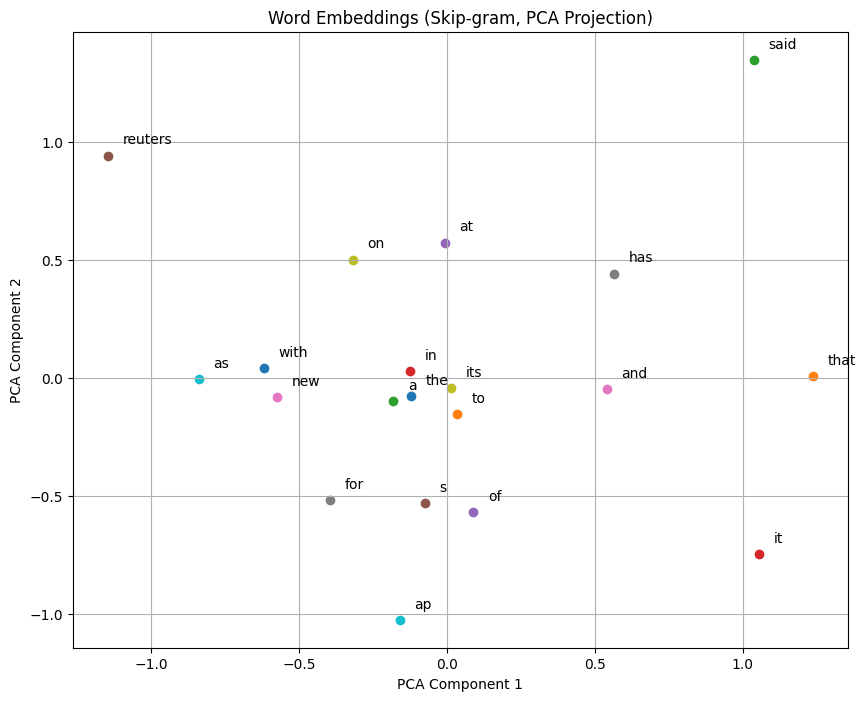

In [12]:

num_words_to_visualize = 20 # Adjust this number to visualize more or fewer words
viz_words = list(tokenizer.word_index.keys())[:num_words_to_visualize]
indices = [tokenizer.word_index[w] for w in viz_words]
vectors = embeddings[indices]

reduced = PCA(n_components=2).fit_transform(vectors)

plt.figure(figsize=(10, 8)) # Increased figure size for better readability
for i, w in enumerate(viz_words):
    plt.scatter(reduced[i, 0], reduced[i, 1])
    plt.annotate(w, (reduced[i, 0] + 0.05, reduced[i, 1] + 0.05)) # Added slight offset for annotation

plt.title("Word Embeddings (Skip-gram, PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()



## 8️⃣ Visual Comparison: CBOW vs Skip-gram Embeddings

This section compares CBOW and Skip-gram word embeddings using **PCA visualization**.
The same set of words is projected into 2D space to highlight differences in how
each model learns semantic representations.


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.7924
Epoch 2/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.4004
Epoch 3/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9339
Epoch 4/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7595
Epoch 5/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.6383
Epoch 6/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 6.5692
Epoch 7/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.5081
Epoch 8/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4102
Epoch 9/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2850
Epoch 10/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1239


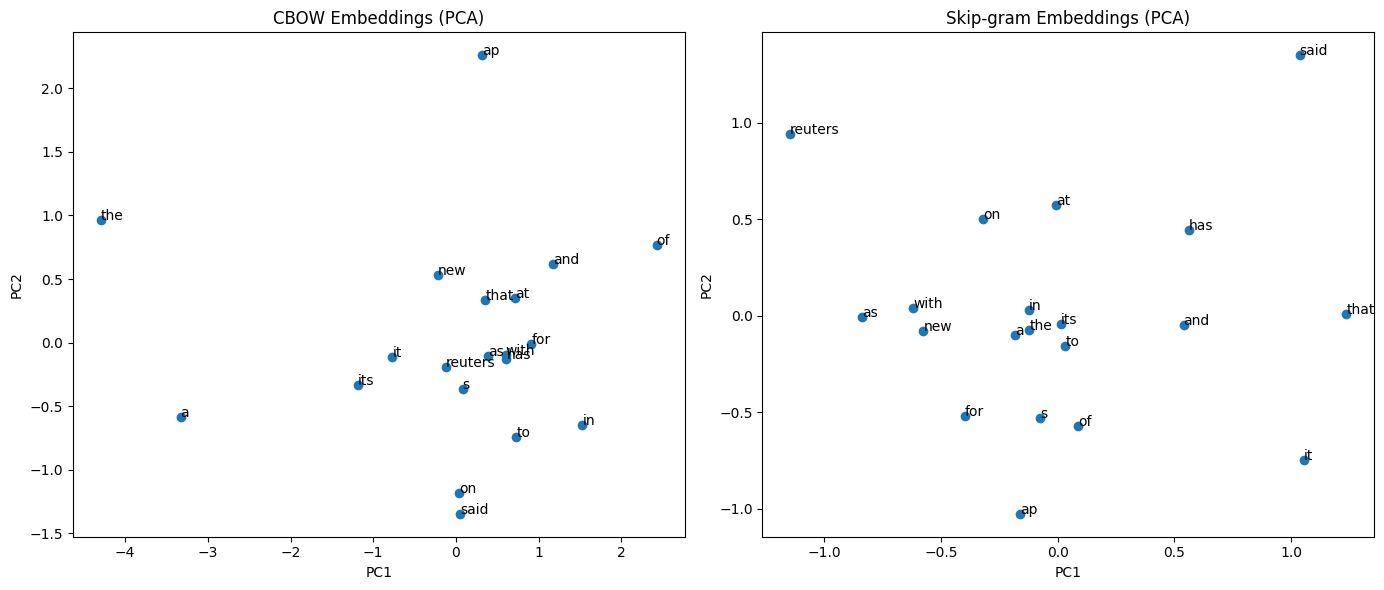

In [13]:

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Select words to visualize
NUM_WORDS = 20
words = list(tokenizer.word_index.keys())[:NUM_WORDS]
indices = [tokenizer.word_index[w] for w in words]

# CBOW embeddings
cbow_embedding_layer = train_cbow(sequence, VOCAB_LIMIT)
cbow_embeddings = cbow_embedding_layer.get_weights()[0]
cbow_vecs = cbow_embeddings[indices]

# Skip-gram embeddings (already trained)
skipgram_vecs = embeddings[indices]

# PCA projection
pca = PCA(n_components=2)
cbow_2d = pca.fit_transform(cbow_vecs)
skipgram_2d = pca.fit_transform(skipgram_vecs)

plt.figure(figsize=(14, 6))

# CBOW plot
plt.subplot(1, 2, 1)
plt.scatter(cbow_2d[:, 0], cbow_2d[:, 1])
for i, word in enumerate(words):
    plt.annotate(word, (cbow_2d[i, 0], cbow_2d[i, 1]))
plt.title("CBOW Embeddings (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

# Skip-gram plot
plt.subplot(1, 2, 2)
plt.scatter(skipgram_2d[:, 0], skipgram_2d[:, 1])
for i, word in enumerate(words):
    plt.annotate(word, (skipgram_2d[i, 0], skipgram_2d[i, 1]))
plt.title("Skip-gram Embeddings (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()
